In [11]:
from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parents[0])
import pandas as pd
import jax.numpy as jnp
from pathlib import Path
from jaxkineticmodel.load_sbml.sbml_model import SBMLModel
from scripts.data_generation import generate_training_data, load_data_from_csvs
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.nn as jnn
import diffrax
import optax
import matplotlib.pyplot as plt


In [ ]:
# # #Change the stoichiometric matrix to make sure the mass balance closes

# filepath = "models/pCA_model_v1.xml"

# sbmlModel = SBMLModel(filepath)
# kinetic_model = sbmlModel.get_kinetic_model()
# sbmlModel = SBMLModel(filepath)
# sbmlModel.parameters



# kinetic_model.stoichiometry.loc['co2', 'v_product'] = 1
# kinetic_model.stoichiometry.loc['co2', 'v_biomass'] = 0
# kinetic_model.stoichiometry.loc['e4p', 'v_sink_e4p'] = 0
# kinetic_model.stoichiometry.loc['pep', 'v_sink_pep'] = 0
# kinetic_model.stoichiometry.loc['epsp', 'v_sink_epsp'] = 0
# kinetic_model.stoichiometry.loc['c_biomass', 'v_biomass'] = 42

# kinetic_model.func.stoichiometry = jnp.array(kinetic_model.stoichiometry)

# output_dir = "models/"
# model_name = "pCA_model_no_sink"
# kinetic_model.func
# sbml = SBMLExporter(model=kinetic_model)

# sbml.export(initial_conditions=sbmlModel.y0,
#             parameters=sbmlModel.parameters,
#             output_file=f"{output_dir}/{model_name}.xml")


In [ ]:
# filepath = "models/sbml_models/pCA_model_v1.xml"
filepath = 'models/sbml_models/pCA_model_changed_S.xml'
# filepath = 'models/sbml_models/pCA_model_no_sink.xml'
model_name = "pCA_model"


# Load model 
sbmlModel = SBMLModel(filepath)
kinetic_model = sbmlModel.get_kinetic_model()


sbmlModel = SBMLModel(filepath)
sbmlModel.parameters

S = sbmlModel._get_stoichiometric_matrix() 


ts = jnp.linspace(0, 40, 40).round()

ts_7 = jnp.linspace(0, 40, 8).round()

# Simulate model with original parameters for 8 and 40 timepoints
ys_7 = kinetic_model(ts_7, sbmlModel.y0, sbmlModel.parameters)
ys = kinetic_model(ts, sbmlModel.y0, sbmlModel.parameters)


ys = jnp.where(jnp.abs(ys) < 1e-9, 0.0, ys)



ys = pd.DataFrame(ys,columns=S.index)
ys_7 = pd.DataFrame(ys_7,columns=S.index)


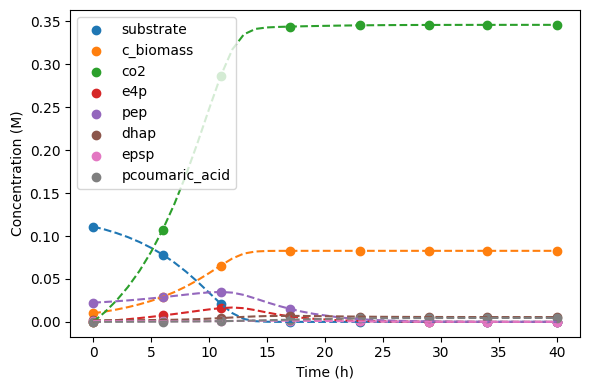

In [9]:
plt.figure(figsize=(6, 4))

for key in ys.keys():
    # if key != "co2" and key != "substrate" and key != "c_biomass":
        plt.scatter(ts_7, ys_7[key], label=key)
        plt.plot(ts, ys[key], linestyle="--")
   

plt.xlabel("Time (h)")
plt.ylabel("Concentration (M)")
plt.legend()
plt.tight_layout()
# plt.ylim(-0.1, 0.3)
plt.show()

In [ ]:
# Create dataset of perturbed strains

parameter_perturbations = {'vmax_v1': np.linspace(0.1, 0.9, 20),
                        'vmax_respiration': np.linspace(0.1, 0.9, 20),
                        'vmax_ppp': np.linspace(0.1, 0.9, 20),
                        'vmax_glyc': np.linspace(0.1, 0.9, 20),
                        'vmax_shiki_step1': np.linspace(0.1, 0.9, 20),
                        'vmax_shiki_step2': np.linspace(0.1, 0.9, 20),
                        'vmax_product': np.linspace(0.1, 0.9, 20),
                        'vmax_sink2_pep': np.linspace(0.1, 0.9, 20),
                        'vmax_sink1_e4p': np.linspace(0.1, 0.9, 20),
                        'vmax_sink3_epsp': np.linspace(0.1, 0.9, 20)}

# generate_training_data(filepath, ts, parameter_perturbations, model_name, 3000)

[0.1        0.14210526 0.18421053 0.22631579 0.26842105 0.31052632
 0.35263158 0.39473684 0.43684211 0.47894737 0.52105263 0.56315789
 0.60526316 0.64736842 0.68947368 0.73157895 0.77368421 0.81578947
 0.85789474 0.9       ]


In [33]:
#Load the data
ts, ys_total, params_total, _ = load_data_from_csvs(
    csv_dir="data",
    metabolites= sbmlModel.species_names,
    model_name = model_name,
)

ts_noise, ys_total_noise, params_total_noise, _ = load_data_from_csvs(
    csv_dir="data_noise_20",
    metabolites= sbmlModel.species_names,
    model_name = model_name,
)

cross_data = ys_total[:, -1, -1].reshape(-1, 1, 1)


ys_one_reaction = ys_total[:, :, (0, 1, 2, -1)] #Substrate, CO2, biomass and product
y0_one_reaction = jnp.array([sbmlModel.y0[i] for i in (0, 1, 2, -1)])

ys_3_points = ys_total[:, (0, 2, 4, 6), :]
ys_end = ys_total[:, (0, 6), :]
ts_3 = ts[0::2]
ts_end = ts[0::6]


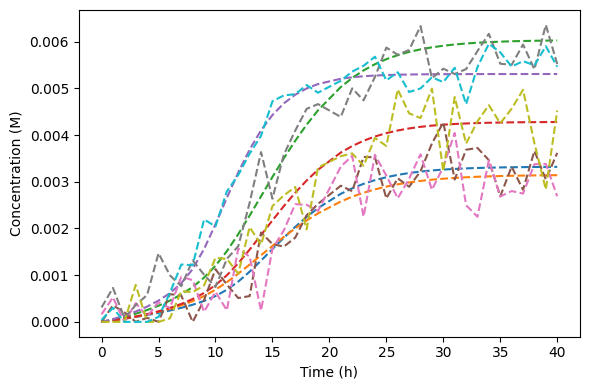

In [34]:
plt.figure(figsize=(6, 4))
plt.plot(ts, ys_total[:5, :, -1].T, linestyle="--")
plt.plot(ts, ys_total_noise[:5, :, -1].T, linestyle="--")

plt.xlabel("Time (h)")
plt.ylabel("Concentration (M)")
plt.tight_layout()
# plt.ylim(-0.1, 0.3)
plt.show()